# **Simulation**

For so-called weathering (supply) limitation, $W \ll 1/4$:

\begin{equation}
    \lim_{W\rightarrow\infty} \nu_s \approx 1+W
    \quad\Leftrightarrow\quad
    u_s \approx  u_0 + {\lambda}{w_0}
\end{equation}

For so-called erosion limitation (unlimited supply), $W \gg 2.5$:

\begin{equation}
    \lim_{W\rightarrow\infty} \nu_s \approx \dfrac{1}{2}+ \sqrt{W}
    \quad\Leftrightarrow\quad
    u_s \approx \dfrac{1}{2}+\sqrt{{\lambda}{w_0 u_0}}
\end{equation}



### Preliminaries

In [1]:
from essentials import *

In [2]:
equations = Equations()
viz = VizSimulations(dpi=120,)

# Solutions for range of weathering numbers

## High ${\mathcal{W}}$

In [3]:
physical_parameters = {
    w_0: np.float64(100),
    v_0: np.float64(10),
    k:   np.float64(1)
}
model_parameters = {
    chi_domain_size: 20.0,
    tau_domain_size: 80.0,
    Delta_chi      : 0.005,
    Delta_tau      : 0.005
}
nm_highW = NumericalModel(physical_parameters, model_parameters,)
nm_highW.model_parameters
nm_highW.solve()
nm_highW.physical_parameters

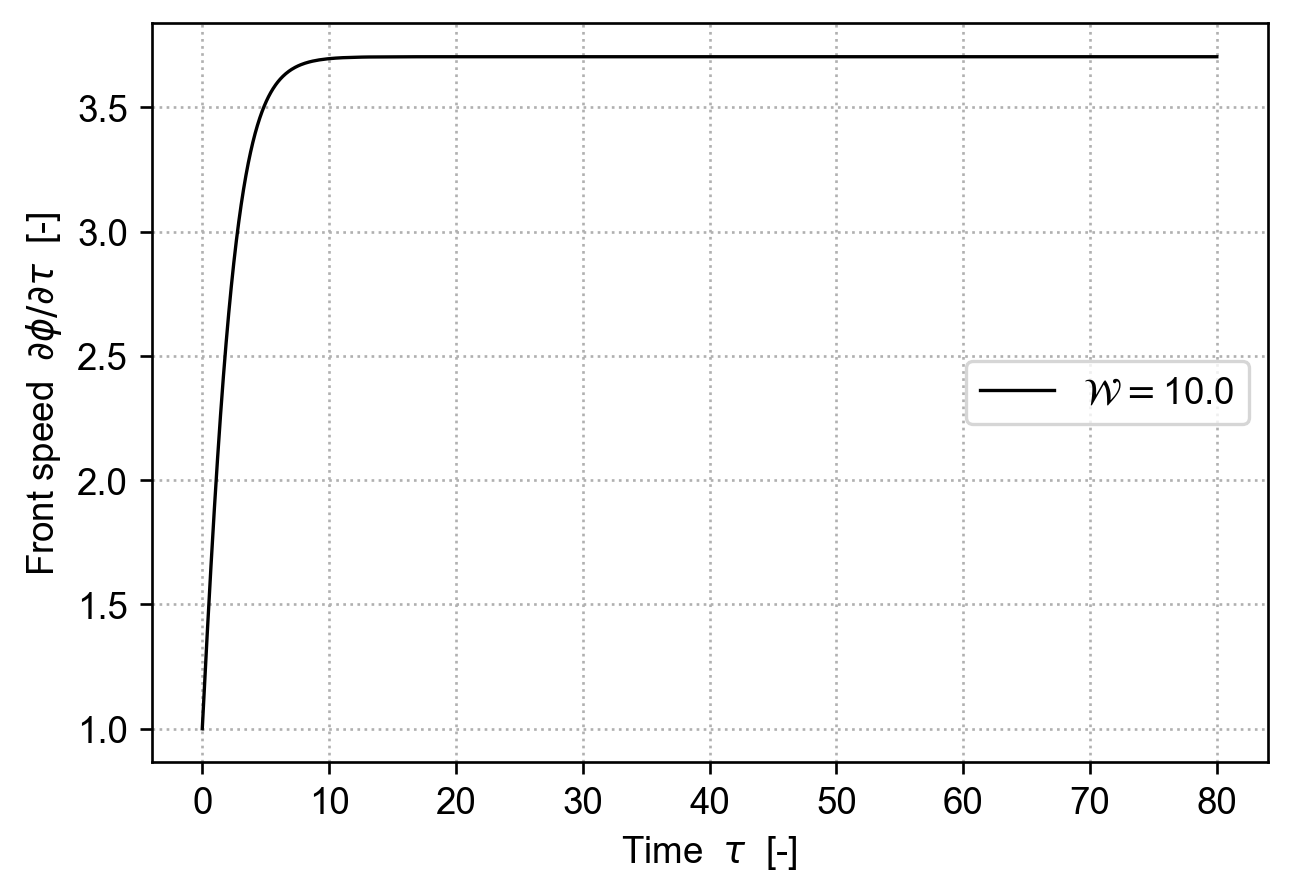

In [4]:
name = "highW_frontspeed_evolution"
viz.front_speed_evolution(name, nm=nm_highW)

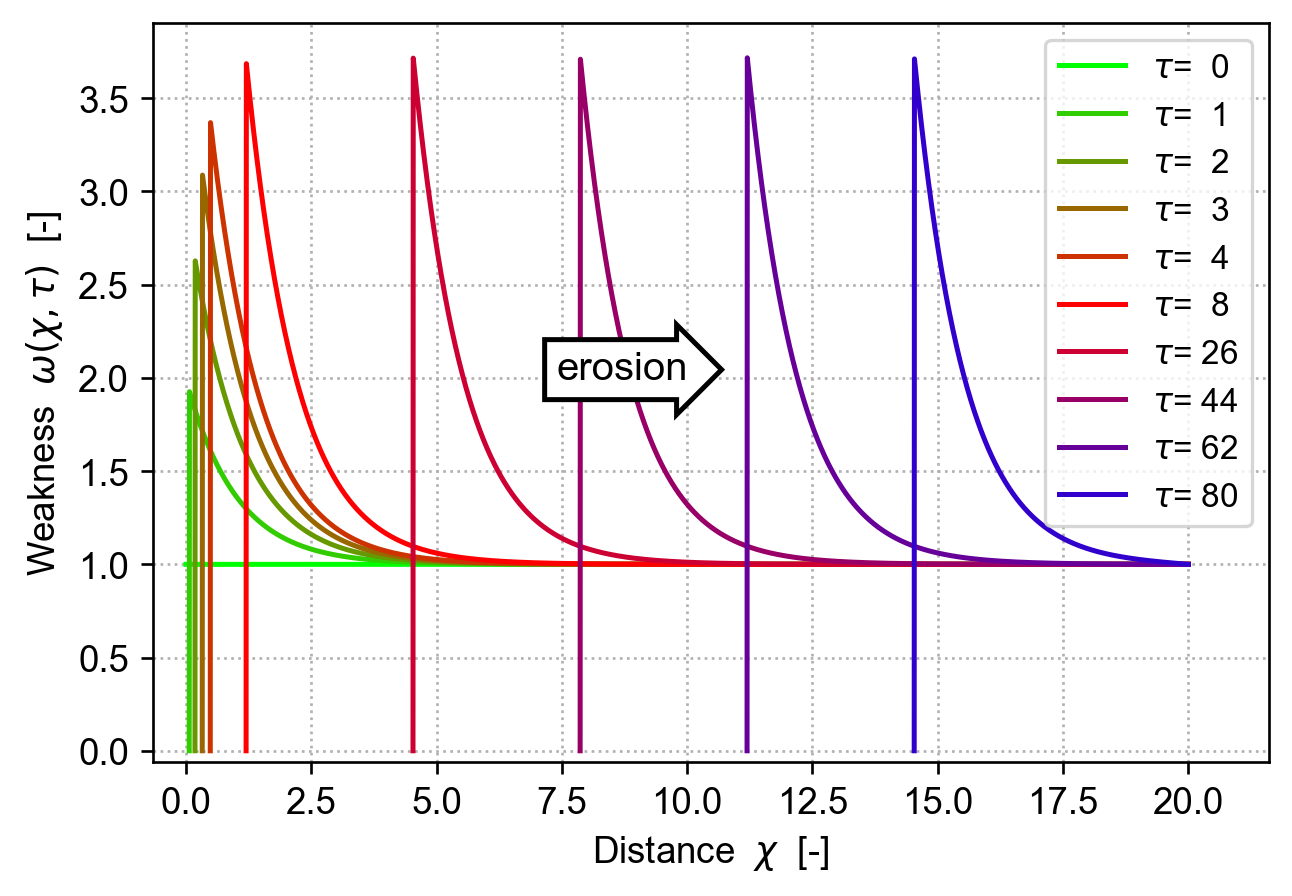

In [5]:
name = "highW_weakness_evolution"
viz.weakness_evolution(name, nm=nm_highW, tc=20, nd=0,)

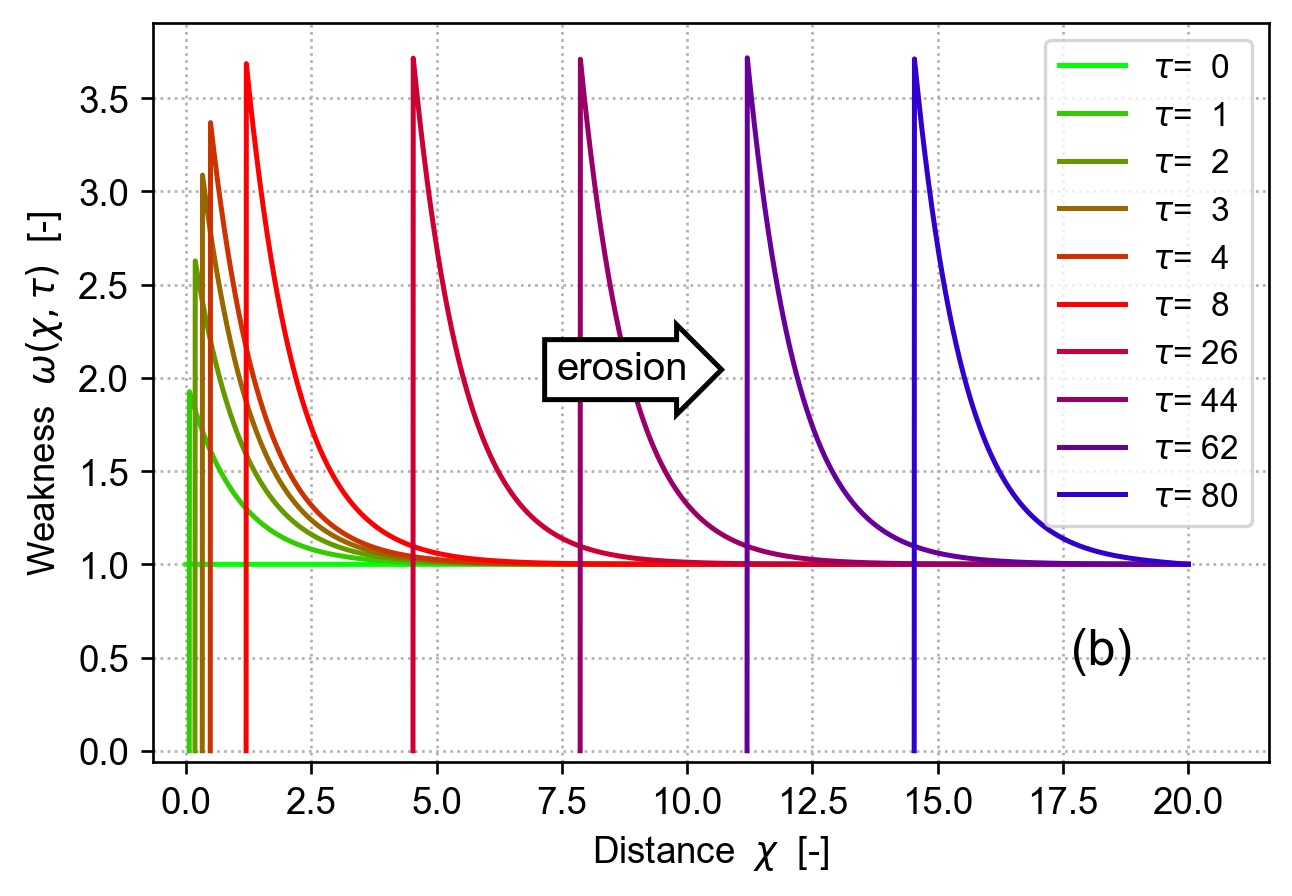

In [6]:
name = "highW_weakness_evolution_subfigb"
viz.weakness_evolution(
    name, nm=nm_highW, tc=20, nd=0, text_label=((0.85,0.15),"(b)",15),
)

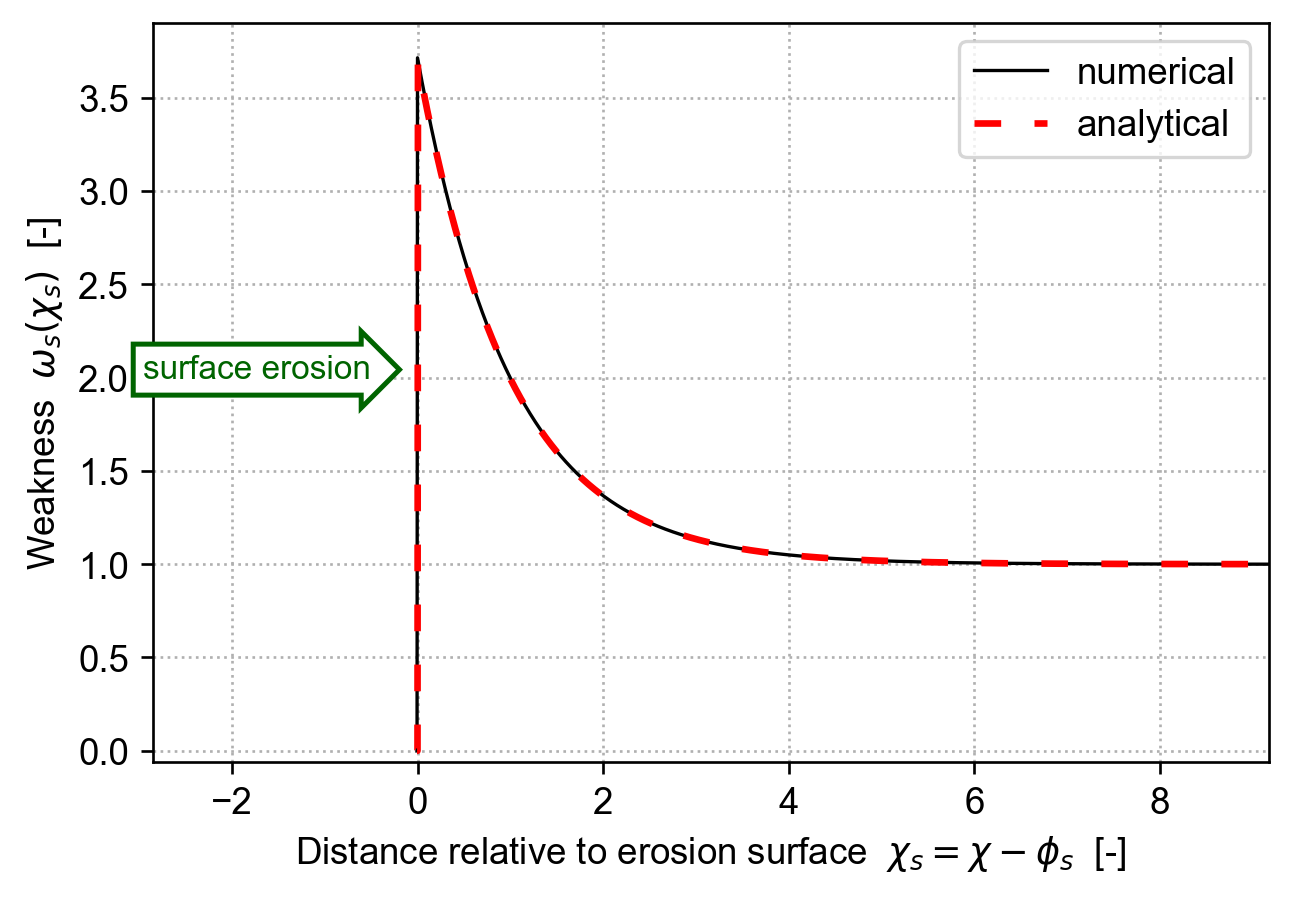

In [7]:
name = "highW_weakness_ss"
viz.weakness_steadystate(name, nm=nm_highW,)

## High transitional ${\mathcal{W}}$

In [8]:
physical_parameters = {
    w_0: np.float64(25),
    v_0: np.float64(10),
    k:   np.float64(1)
}
model_parameters = {
    chi_domain_size: 20.0,
    tau_domain_size: 80.0,
    Delta_chi      : 0.005,
    Delta_tau      : 0.005
}
nm_highTransW = NumericalModel(physical_parameters, model_parameters,)
nm_highTransW.model_parameters
nm_highTransW.solve()
nm_highTransW.physical_parameters

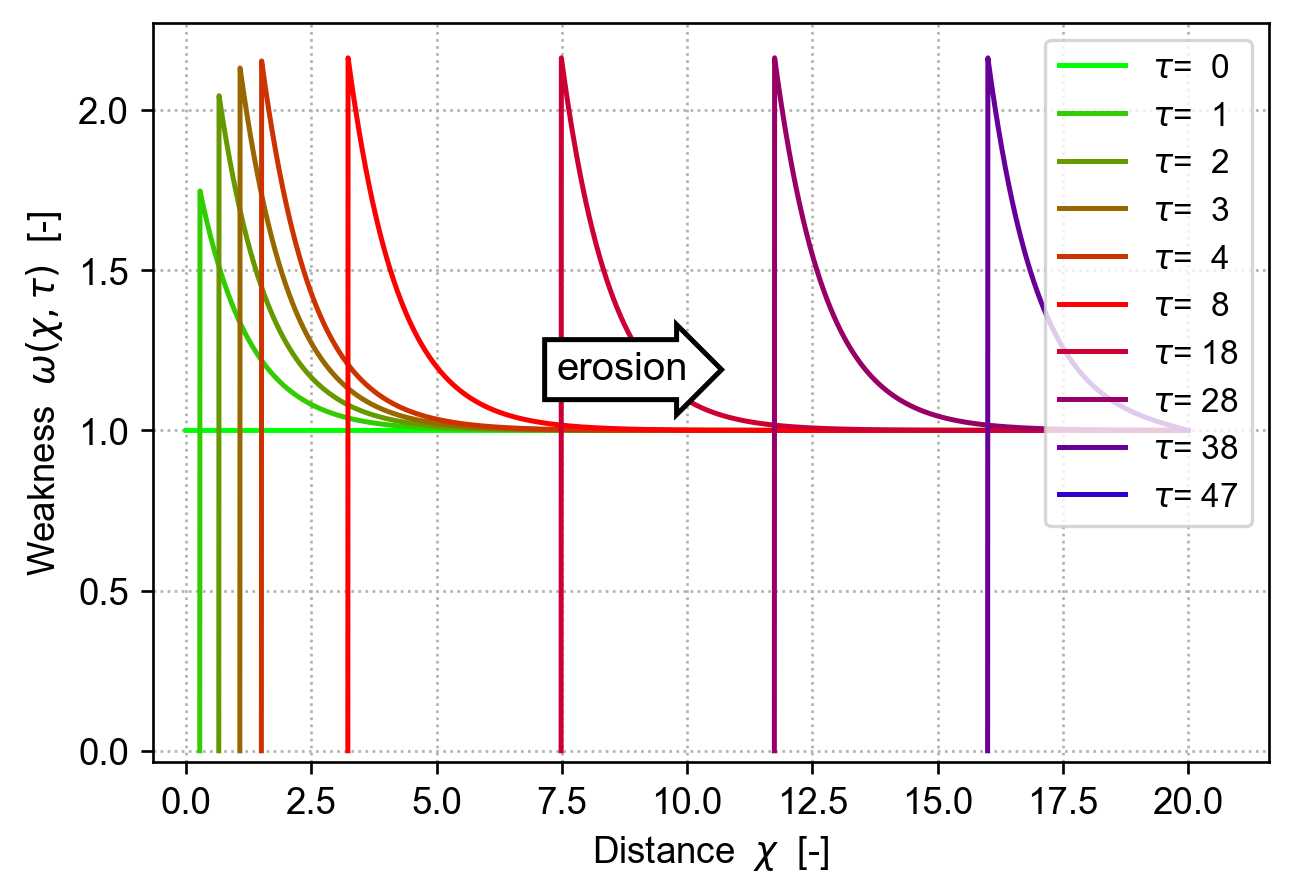

In [9]:
name = "highTransW_weakness_evolution"
viz.weakness_evolution(
    name, nm=nm_highTransW, tc=20, nd=0,
)

## Low-transitional ${\mathcal{W}}$

In [10]:
physical_parameters = {
    w_0: np.float64(2.5),
    v_0: np.float64(10),
    k:   np.float64(1)
}
model_parameters = {
    chi_domain_size: 30.0,
    tau_domain_size: 10.0,
    Delta_chi      : 0.01,
    Delta_tau      : 0.003
}
nm_lowTransW = NumericalModel(physical_parameters, model_parameters,)
nm_lowTransW.model_parameters
nm_lowTransW.solve()
nm_lowTransW.physical_parameters

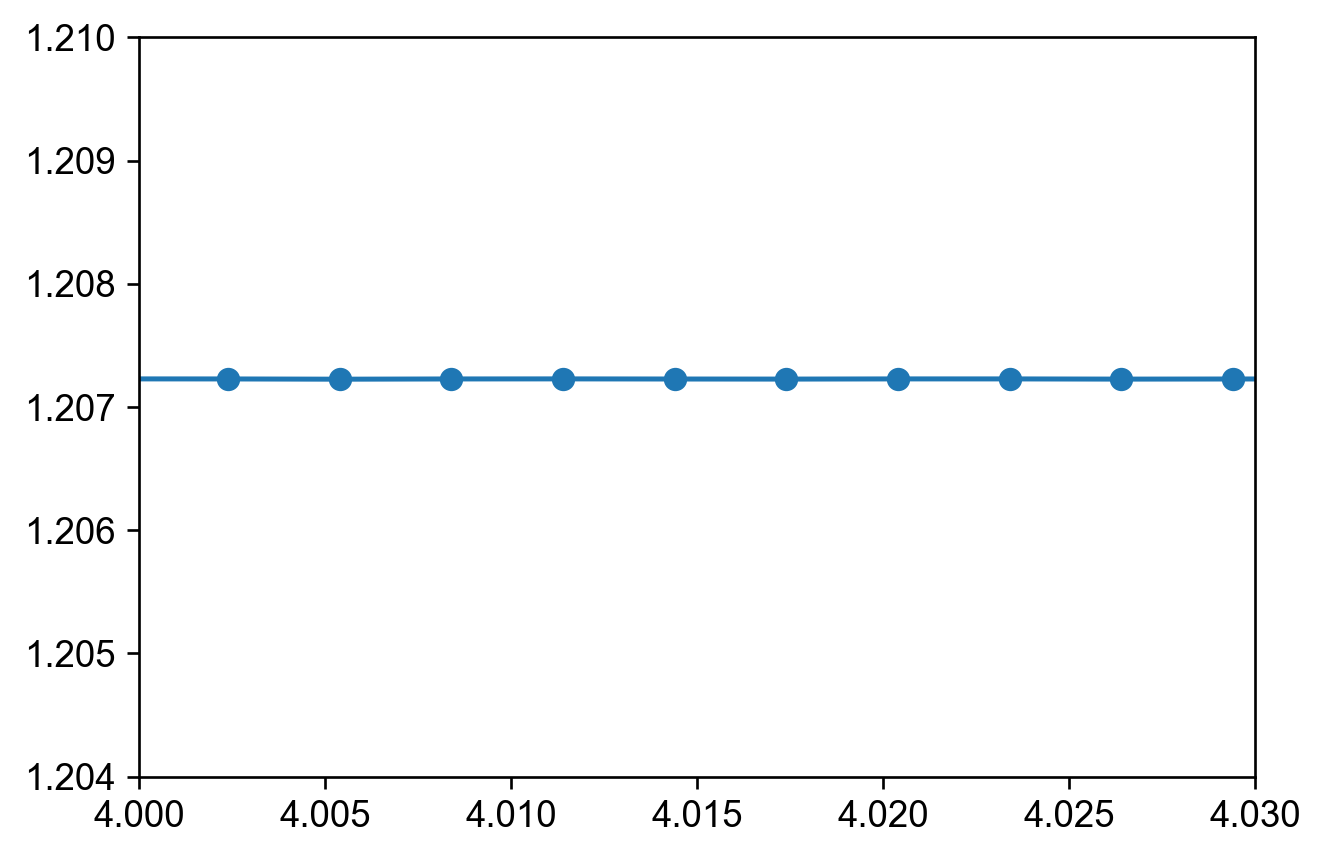

In [11]:
name = "stability_check"
viz.stability_check(
    name, tau=nm_lowTransW.tau_array, nu=nm_lowTransW.nu_array,
)

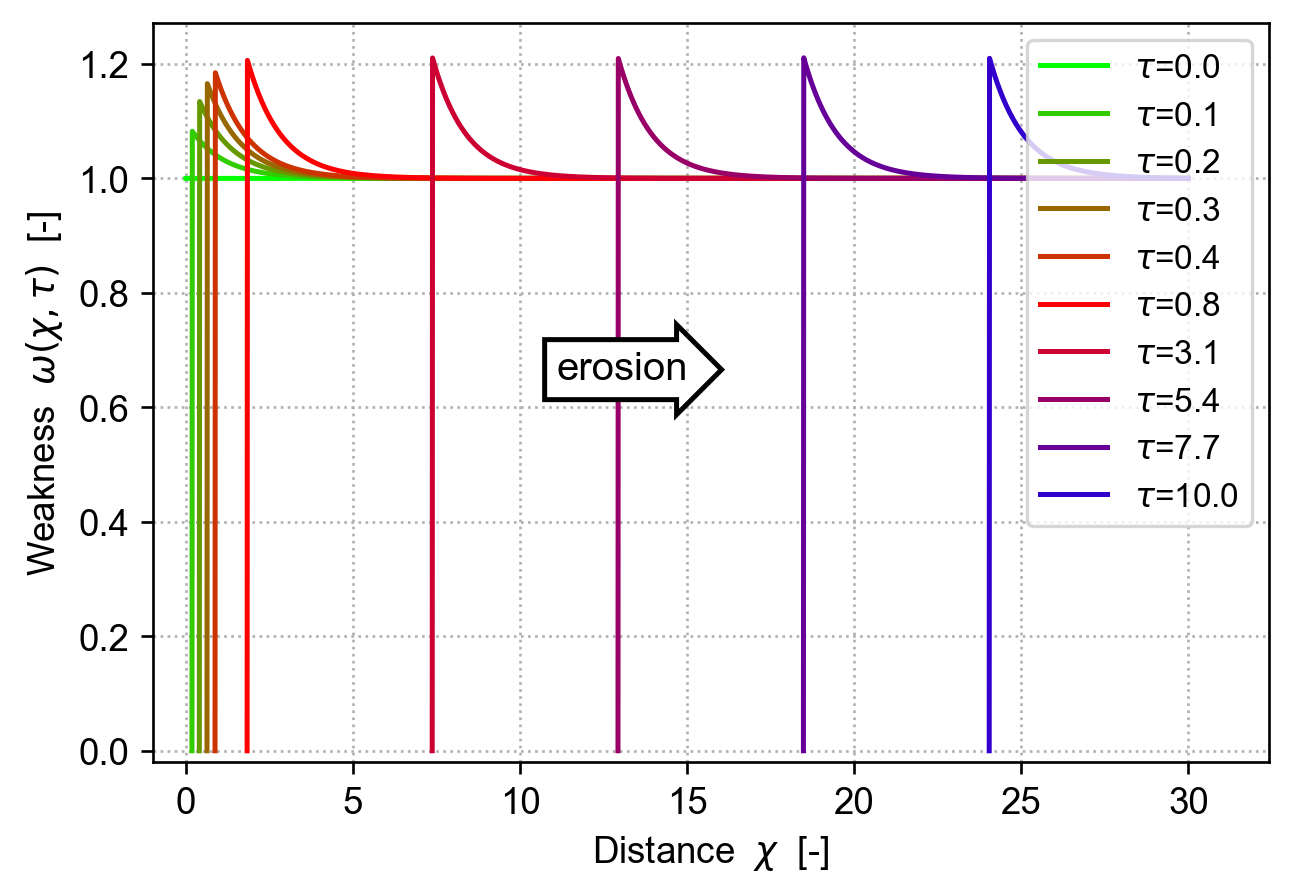

In [12]:
name = "lowTransW_weakness_evolution"
viz.weakness_evolution(
    name, nm=nm_lowTransW, tc=25, nd=1,
)

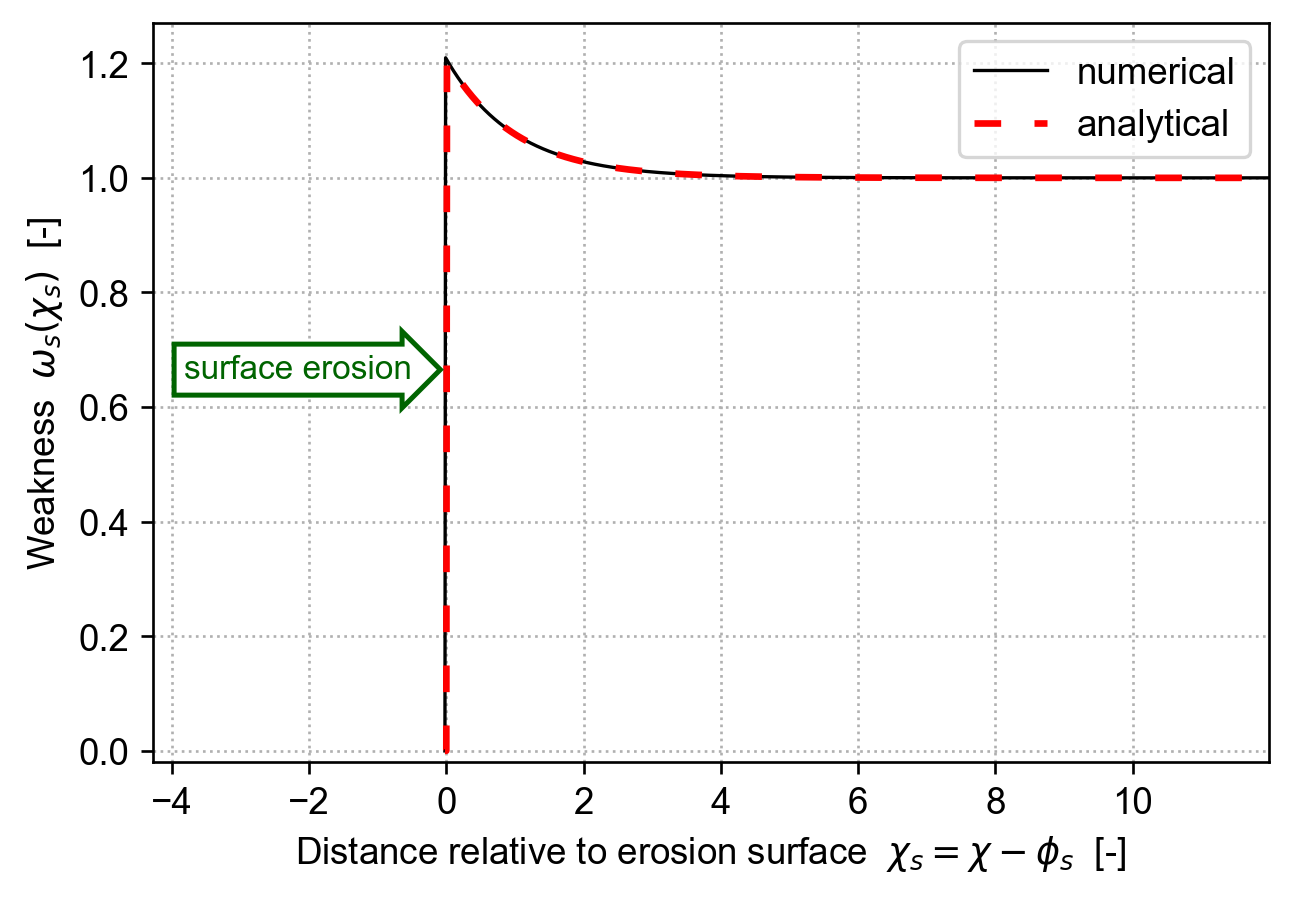

In [13]:
name = "lowTransW_weakness_ss"
viz.weakness_steadystate(name, nm=nm_lowTransW,)

## Low ${\mathcal{W}}$

In [14]:
physical_parameters = {
    w_0: np.float64(0.25),
    v_0: np.float64(10),
    k:   np.float64(1)
}
model_parameters = {
    chi_domain_size: 30.0,
    tau_domain_size: 1.0,
    Delta_chi      : 0.01,
    Delta_tau      : 0.0003
}
nm_lowW = NumericalModel(physical_parameters, model_parameters,)
nm_lowW.model_parameters
nm_lowW.solve()
nm_lowW.physical_parameters

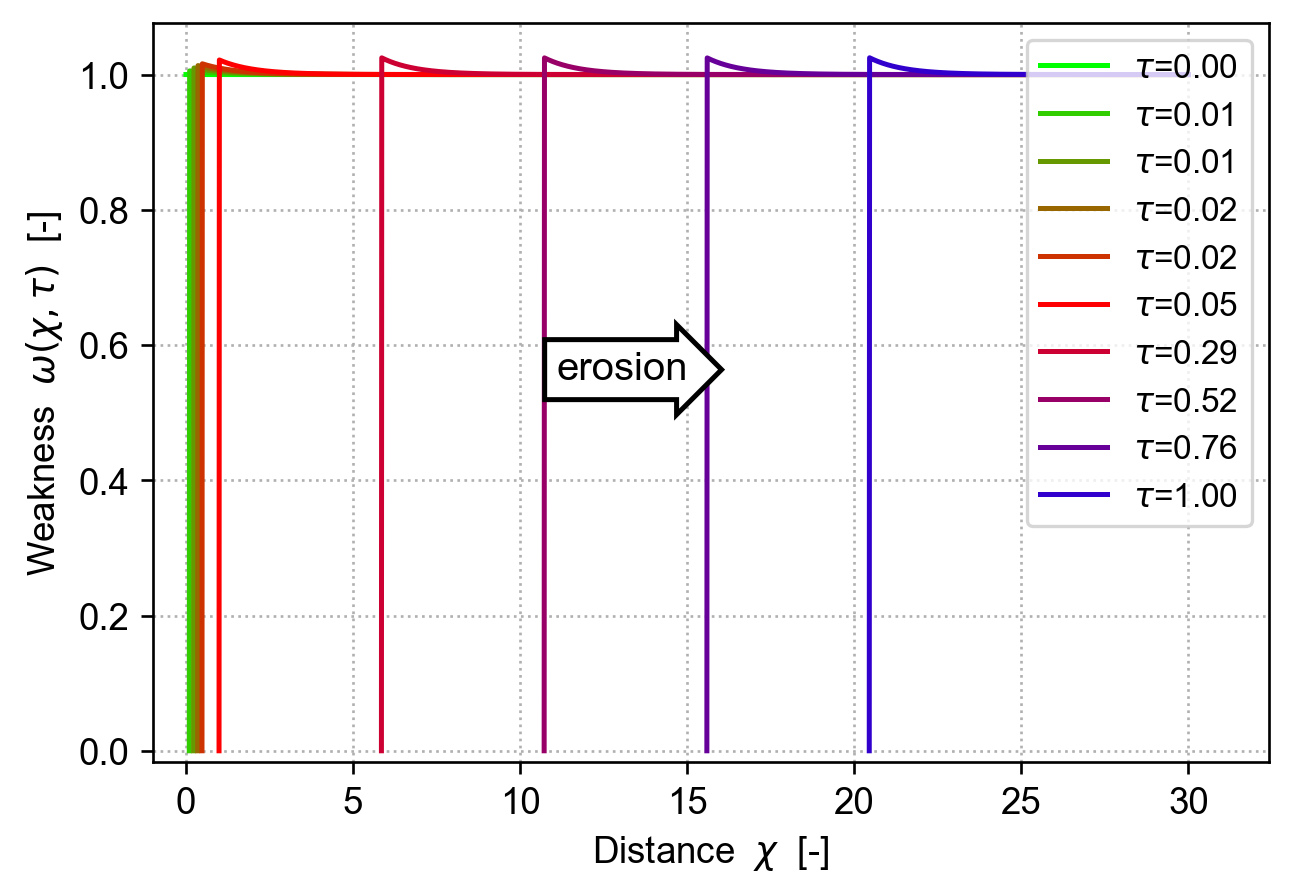

In [15]:
name = "lowW_weakness_evolution"
viz.weakness_evolution(name, nm=nm_lowW,)

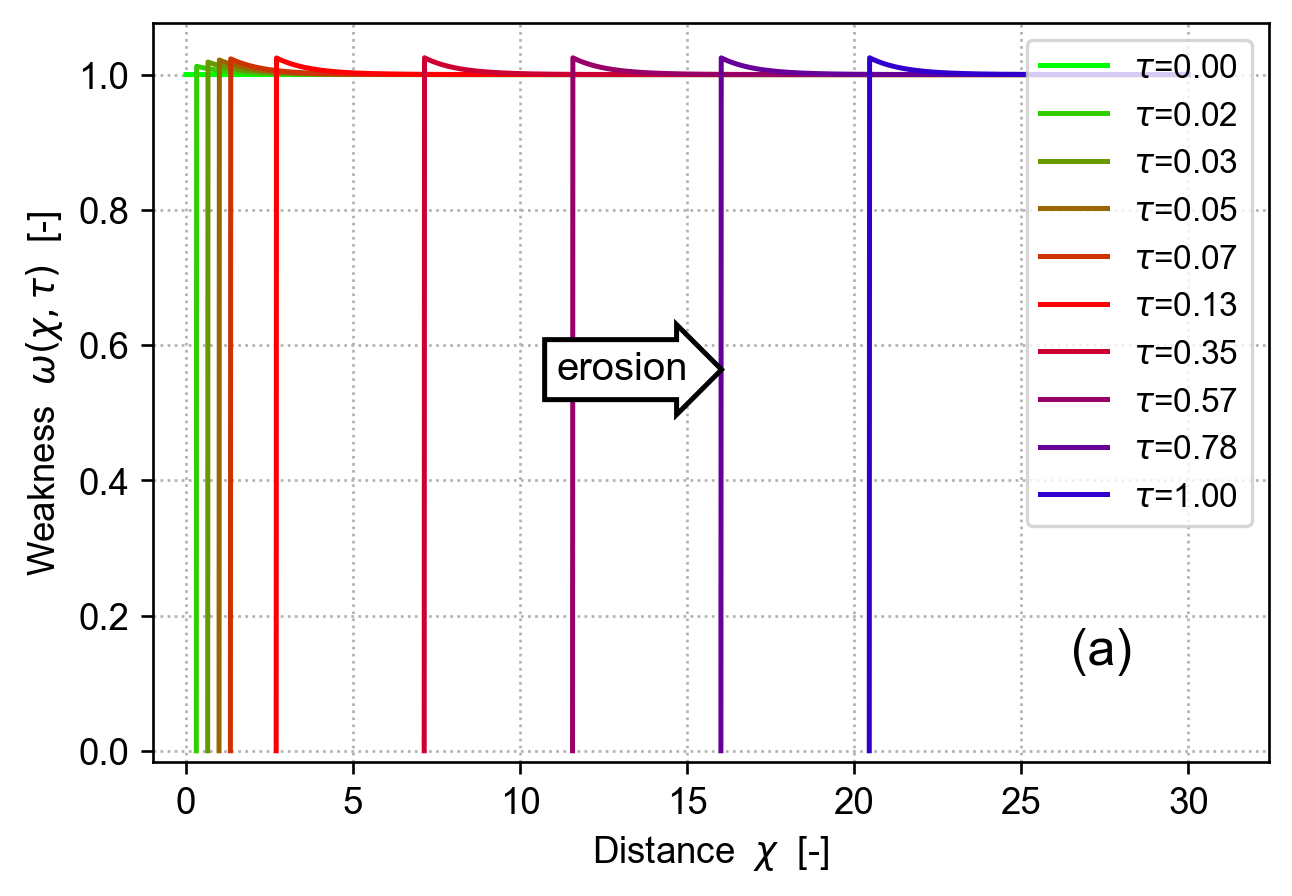

In [16]:
name = "lowW_weakness_evolution_subfiga"
viz.weakness_evolution(
    name, nm=nm_lowW, tc=15, text_label=((0.85,0.15),"(a)",15),
)

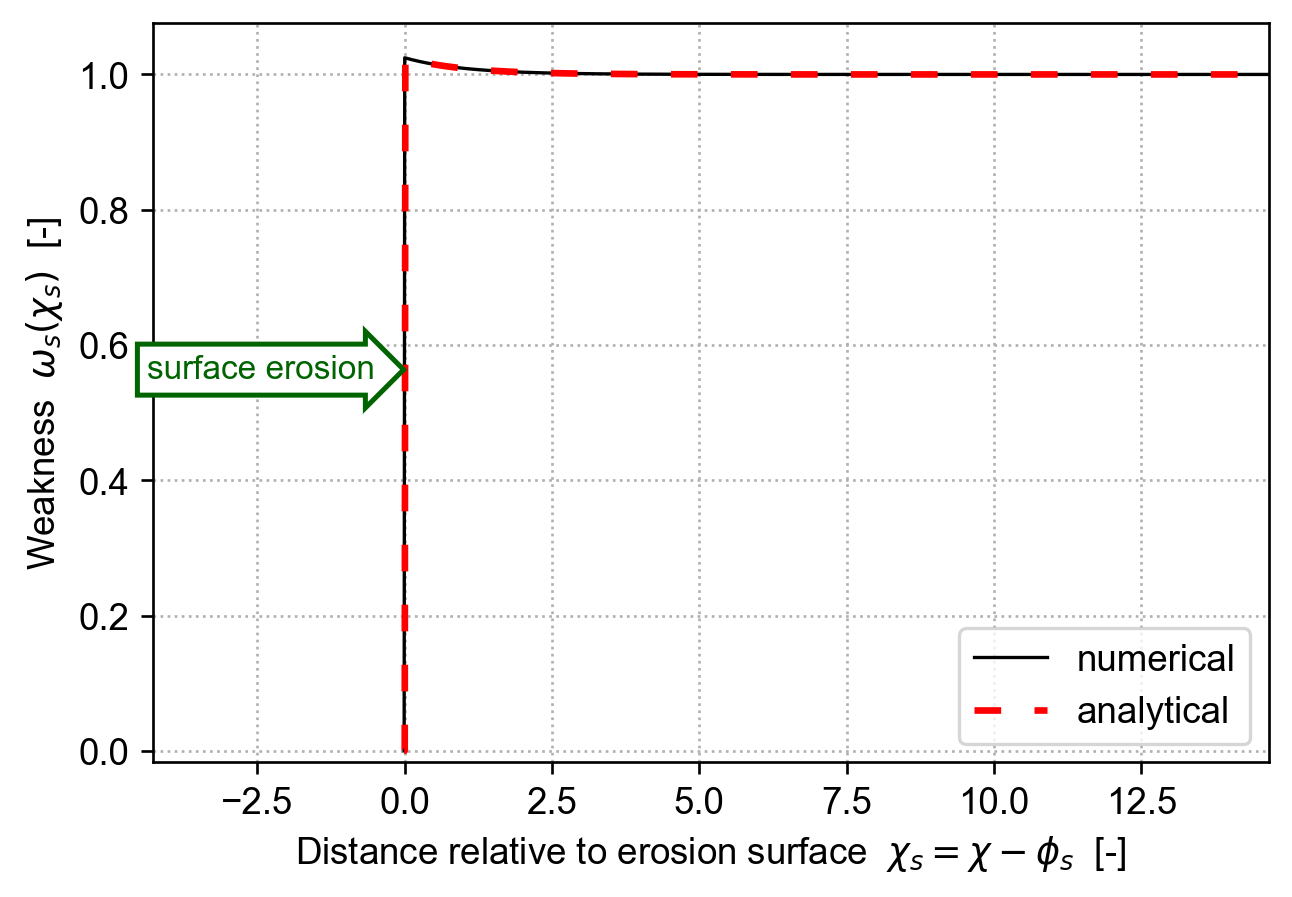

In [17]:
name = "lowW_weakness_ss"
viz.weakness_steadystate(name, nm=nm_lowW,)

# Comparison

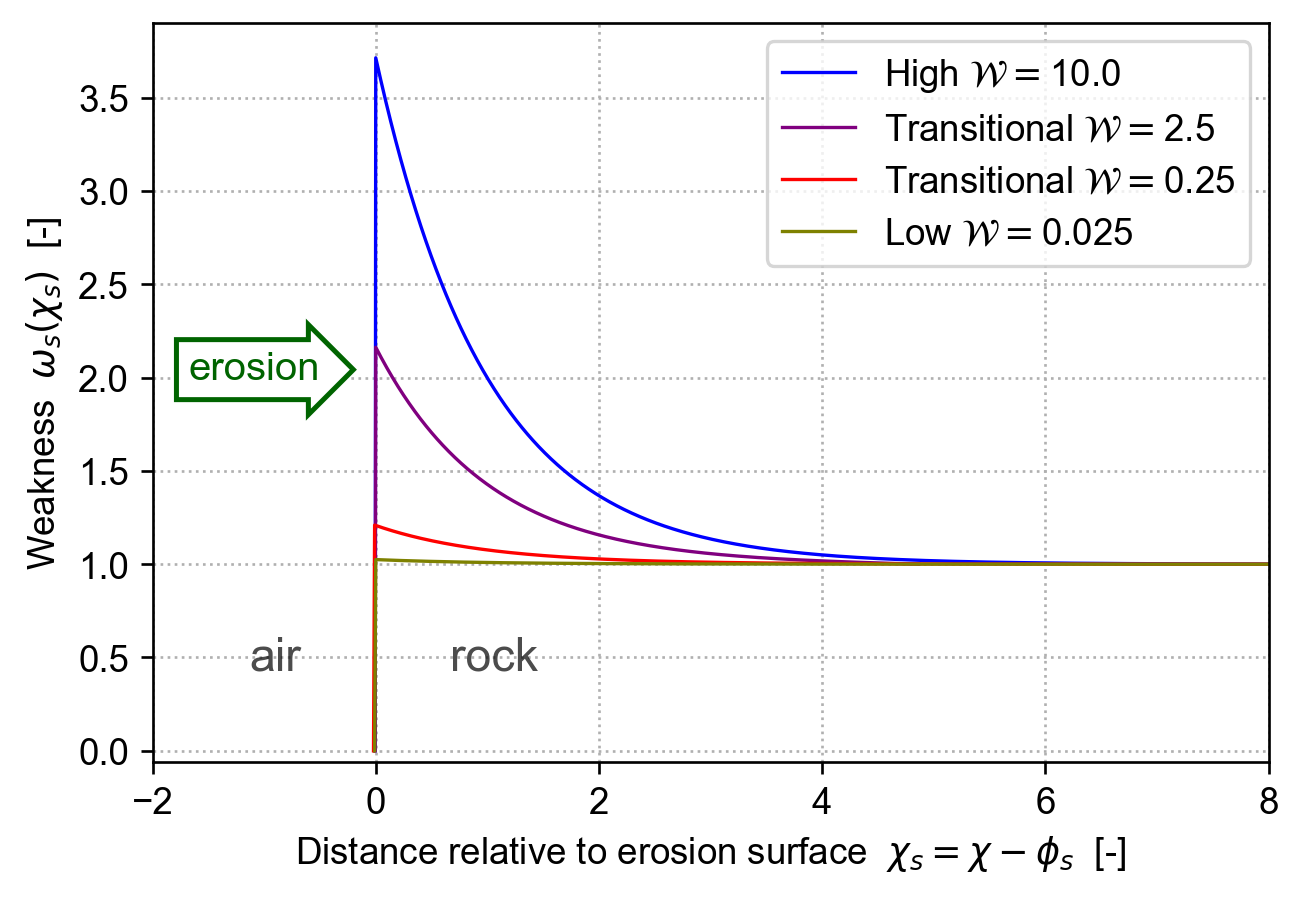

In [18]:
name = "weakness_setW_ss"
numerical_models = (
    (nm_highW, 
        "High ${\mathcal{W}}=$"
        +str(nm_highW.physical_parameters[W])),
    (nm_highTransW,
        "Transitional ${\mathcal{W}}=$"
        +str(nm_highTransW.physical_parameters[W])),
    (nm_lowTransW,
        "Transitional ${\mathcal{W}}=$"
        +str(nm_lowTransW.physical_parameters[W])),
    (nm_lowW,
        "Low ${\mathcal{W}}=$"
        +str(nm_lowW.physical_parameters[W]))
)
viz.weakness_steadystate_setW(name, numerical_models=numerical_models,)

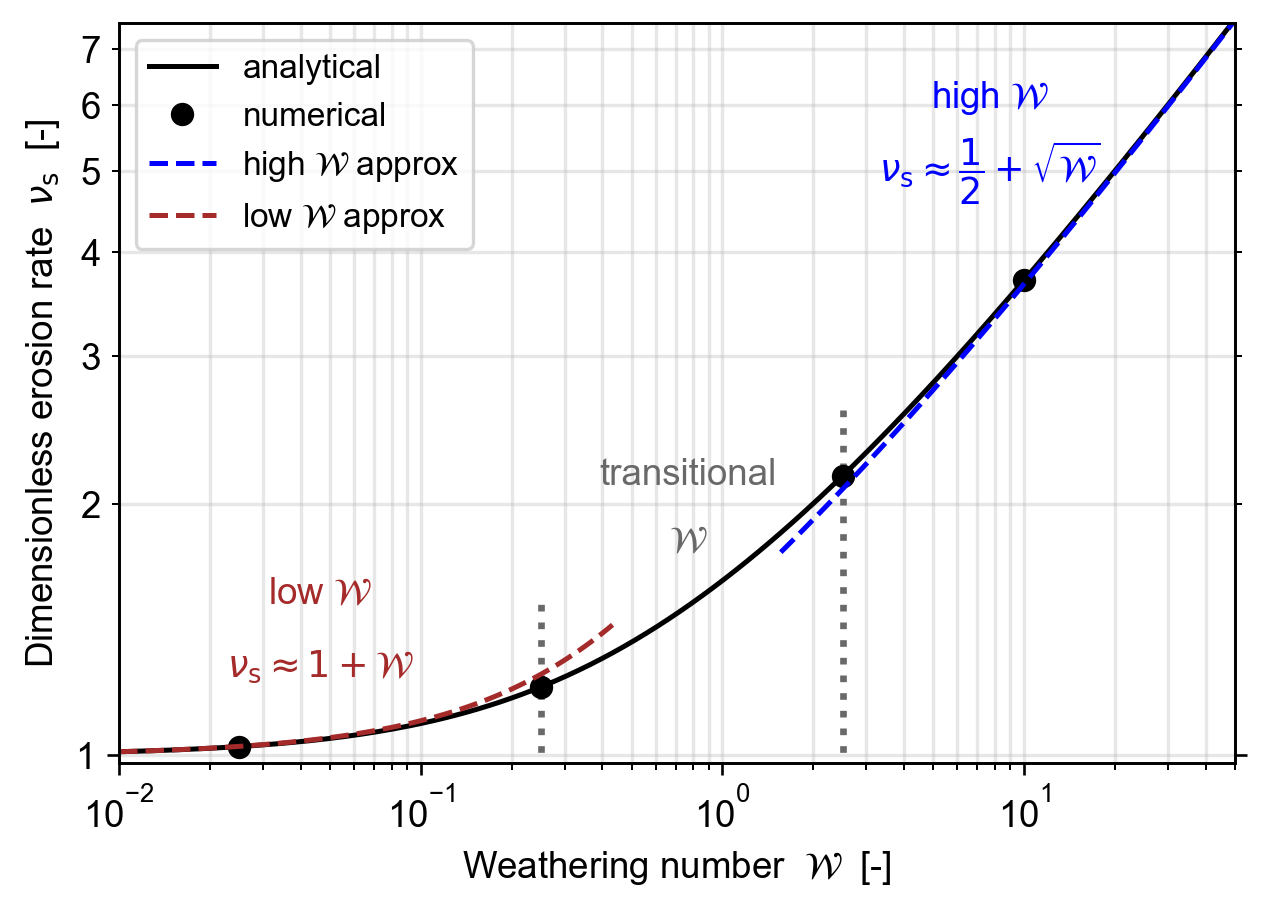

In [19]:
name = "erosionrate_steadystate"
numerical_models = (
    nm_lowW, nm_lowTransW, nm_highTransW, nm_highW,
)
viz.erosion_rate_steadystate_W(
    name, eqns=equations, numerical_models=numerical_models, do_loglog=True,
)

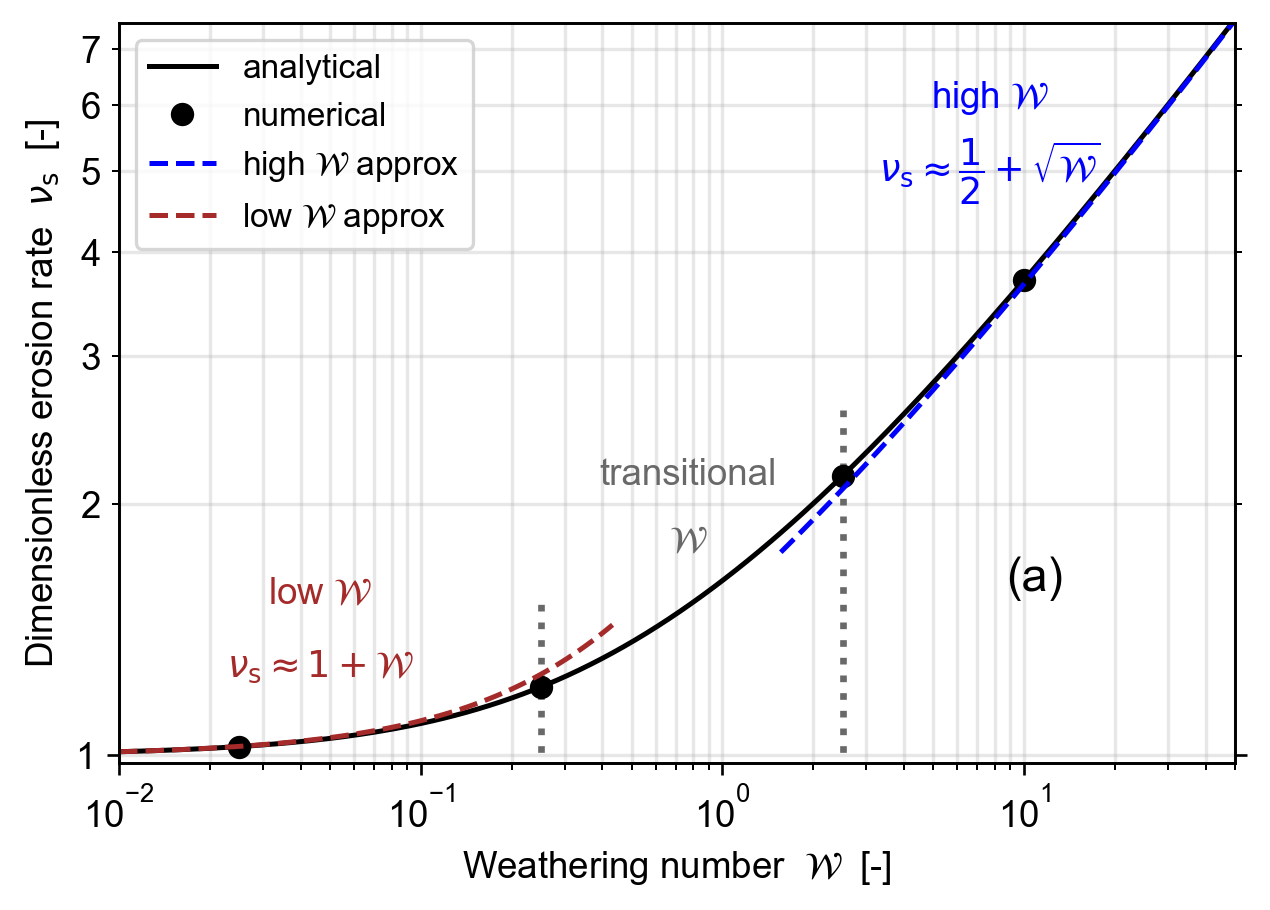

In [20]:
name = "erosionrate_steadystate_subfiga"
numerical_models = (
    nm_lowW, nm_lowTransW, nm_highTransW, nm_highW,
)
viz.erosion_rate_steadystate_W(
    name, 
    eqns=equations, 
    numerical_models=numerical_models, 
    do_loglog=True, 
    text_label="(a)",
)

In [21]:
nus_eqn = sy.Eq( nu_s, (1+sy.sqrt(1+4*W))/2 )
nus_lowW_eqn = sy.Eq( nu_s, 1+W )
nus_highW_eqn = sy.Eq( nu_s, ((sy.Rational(1,2)+sy.sqrt(W))) )
nus_lowW_eqn, nus_eqn, nus_highW_eqn
nus_lowW_error = (
    (nus_lowW_eqn.rhs/nus_eqn.rhs)
    .subs({W:sy.Rational(1,4)}).simplify()
)

In [22]:
# sy.simplify( sy.Eq(nus_eqn.rhs,nus_highW_eqn.rhs*nus_lowW_error) )
# nus_highW_lim=sy.solve(_,W)[0]
# nus_highW_lim
# sy.N(nus_highW_lim)

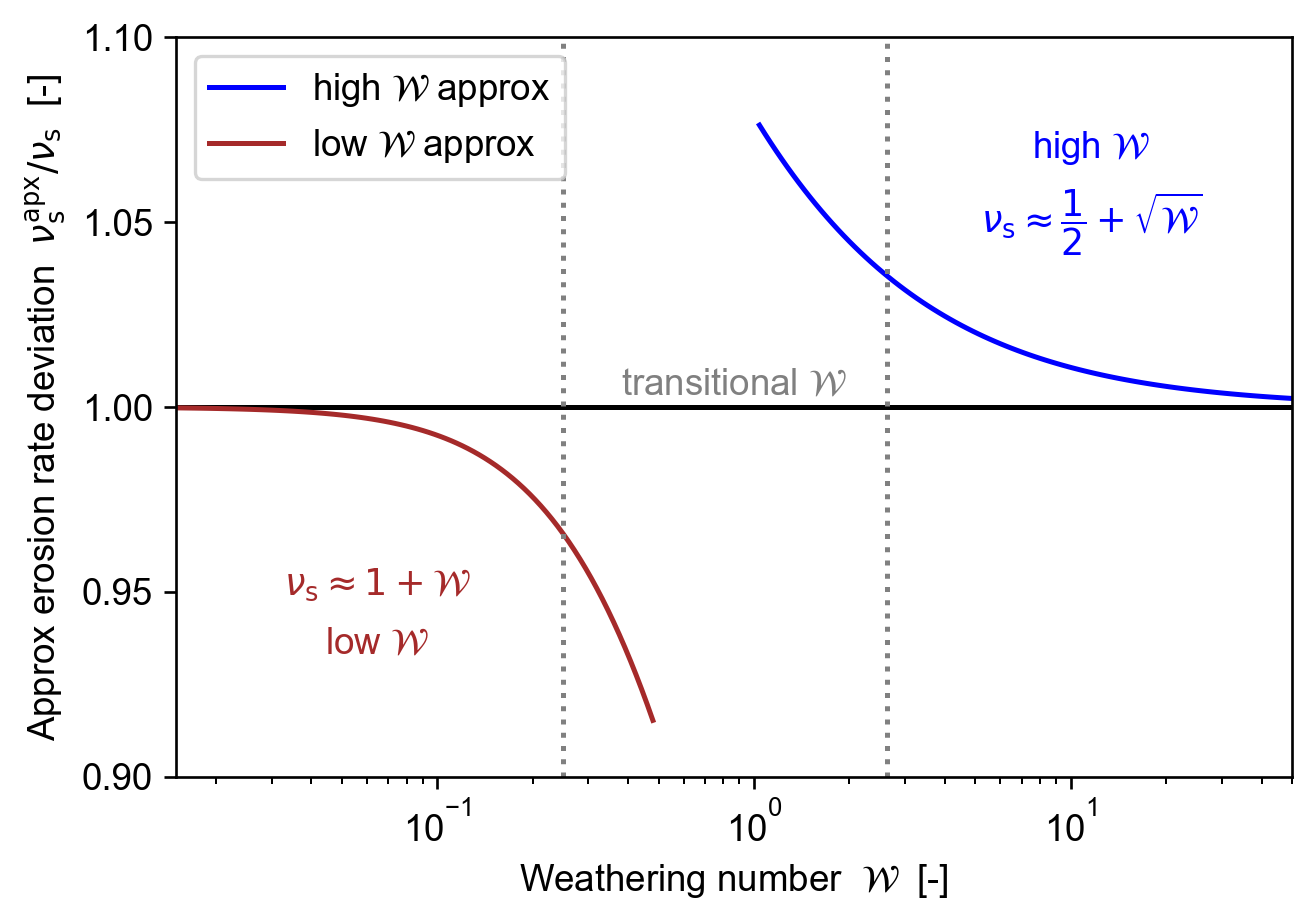

In [23]:
name = "erosionrate_steadystate_approx_devn"
viz.erosion_rate_steadystate_W_transition(name, eqns=equations,)

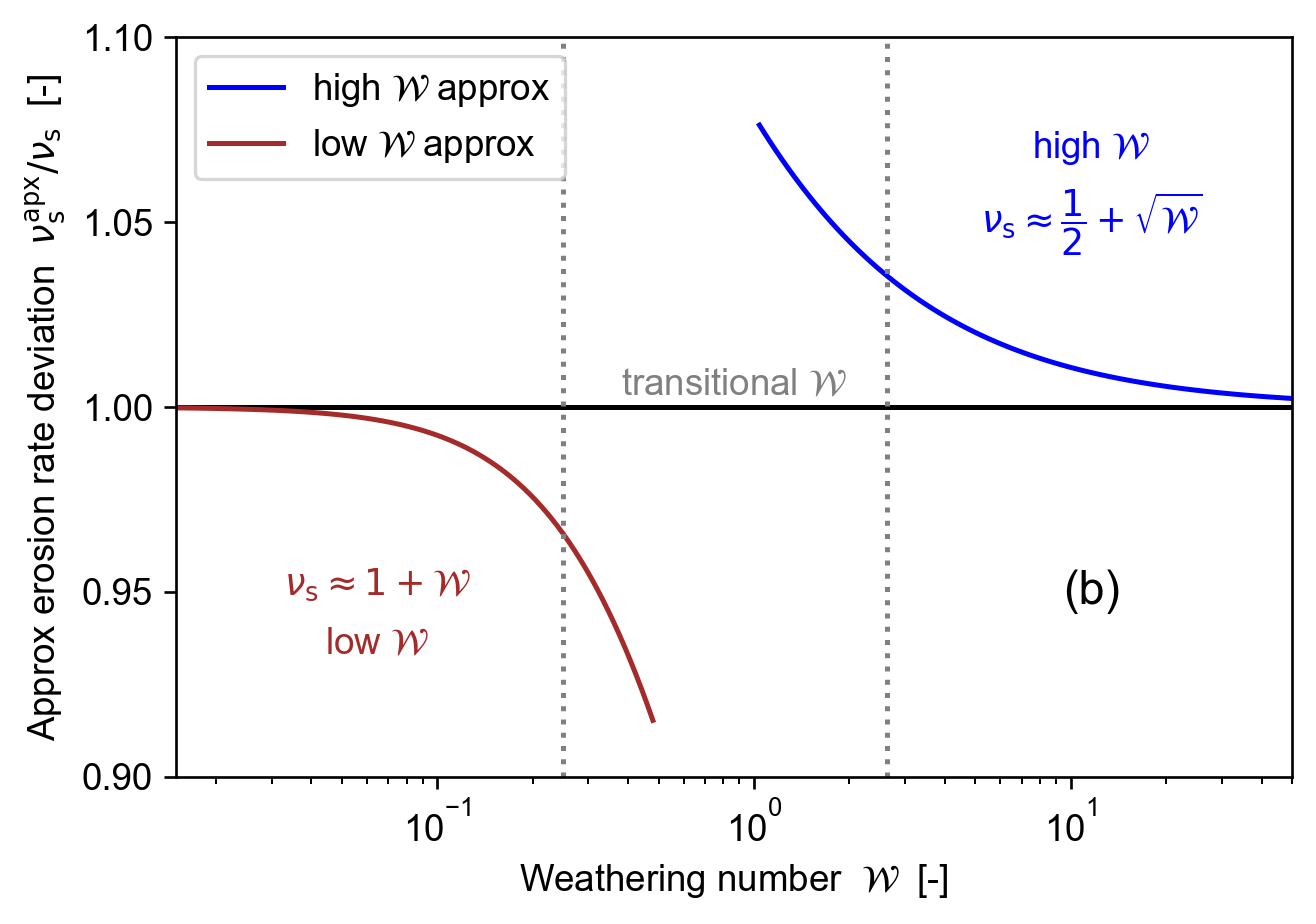

In [24]:
name = "erosionrate_steadystate_approx_devn_subfigb"
viz.erosion_rate_steadystate_W_transition(
    name, eqns=equations, text_label="(b)",
)

# Export

In [25]:
plots_dir: str = create_directories((os.path.curdir,), "plots")
print(tuple(viz.fdict.keys()))
export_plots(
    viz.fdict,
    plots_dir,
    "pdf",
    suffix="",
    dpi=150,
)

('highW_frontspeed_evolution', 'highW_weakness_evolution', 'highW_weakness_evolution_subfigb', 'highW_weakness_ss', 'highTransW_weakness_evolution', 'stability_check', 'lowTransW_weakness_evolution', 'lowTransW_weakness_ss', 'lowW_weakness_evolution', 'lowW_weakness_evolution_subfiga', 'lowW_weakness_ss', 'weakness_setW_ss', 'erosionrate_steadystate', 'erosionrate_steadystate_subfiga', 'erosionrate_steadystate_approx_devn', 'erosionrate_steadystate_approx_devn_subfigb')


'././plots'

In [26]:
for choice in ("erosionrate_steadystate", "highW_weakness_evolution"):
    export_plot(
        choice,
        viz.fdict.get(choice),
        plots_dir,
        "png",
        suffix="",
        dpi=150,
    )